In [1]:
#importing libraries
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymannkendall as mk

In [2]:
#download and extract dataset. if the datasets are already present in the large-data folder, skips to extraction 
if not os.path.isfile('large-data/title.basics.tsv.gz'):
    response = requests.get('https://datasets.imdbws.com/title.basics.tsv.gz')
    if response.status_code == 200:
        with open("large-data/title.basics.tsv.gz", 'wb') as file:
            file.write(response.content)

df = pd.read_csv('large-data/title.basics.tsv.gz', sep='\t', compression='gzip')

if not os.path.isfile('large-data/title.ratings.tsv.gz'):
    response = requests.get('https://datasets.imdbws.com/title.ratings.tsv.gz')
    if response.status_code == 200:
        with open('large-data/title.ratings.tsv.gz', 'wb') as file:
            file.write(response.content)

df2 = pd.read_csv('large-data/title.ratings.tsv.gz', sep='\t', compression='gzip')
df = pd.merge(df, df2, on='tconst') #merge into one pd.DF

/var/folders/n7/xqx0_17x5f736w2ms947w_yr0000gn/T/ipykernel_11668/963933764.py:8: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('large-data/title.basics.tsv.gz', sep='\t', compression='gzip')


In [3]:
#structure of data
df

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short",5.7,2158
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short",5.5,293
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance",6.5,2202
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short",5.3,187
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short,6.2,2943
...,...,...,...,...,...,...,...,...,...,...,...
1569671,tt9916846,tvEpisode,Episode #3.18,Episode #3.18,0,2009,\N,\N,Drama,5.8,6
1569672,tt9916848,tvEpisode,Episode #3.17,Episode #3.17,0,2009,\N,\N,Drama,5.8,6
1569673,tt9916850,tvEpisode,Episode #3.19,Episode #3.19,0,2010,\N,\N,Drama,5.8,6
1569674,tt9916852,tvEpisode,Episode #3.20,Episode #3.20,0,2010,\N,\N,Drama,5.8,6


In [ ]:
#what entry types are there?
df['titleType'].unique()

array(['short', 'movie', 'tvShort', 'tvMovie', 'tvEpisode', 'tvSeries',
       'tvMiniSeries', 'tvSpecial', 'video', 'videoGame'], dtype=object)

In [6]:
#selecting only movies for analysis. delete old df's to free up RAM 
movies_df = df[df['titleType'].isin(['movie'])]
del df, df2

In [7]:
#removing rows with nan values
print(f'n of dropped entries: {len(movies_df[movies_df['runtimeMinutes'] == '\\N']) + len(movies_df[movies_df['startYear'] == '\\N'])} from {len(movies_df)}')
movies_df = movies_df[movies_df['runtimeMinutes'] != '\\N']
movies_df = movies_df[movies_df['startYear'] != '\\N']

#making the columns integers
movies_df['startYear'] = movies_df['startYear'].astype(int)
movies_df['runtimeMinutes'] = movies_df['runtimeMinutes'].astype(int)

n of dropped entries: 33466 from 329875


In [ ]:
#defining function, that sets the period for analysis, does mk test of time lenghts and outputs a boxplot. 
def mov_period_analysis(start_year: int = None, end_year: int = None):
    #Error handling
    if (start_year is not None and end_year is not None) and (start_year > end_year):
        print('Error: Počáteční rok musí být menší, než konečný.')
        return
    if (start_year is not None and not isinstance(start_year, int)) or \
    (end_year is not None and not isinstance(end_year, int)):
        print('Error: Hodnoty musí být celé číslo.')
        return
    
    #set defaults if not provided
    if start_year is None:
        start_year = movies_df['startYear'].min()
    if end_year is None:
        end_year = movies_df['startYear'].max()
    #filter the DF
    filtered = movies_df[(movies_df['startYear'] >= start_year) & (movies_df['startYear'] <= end_year)]
    list_of_lists = filtered.groupby('startYear')['runtimeMinutes'].apply(list).tolist()
    years = sorted(filtered['startYear'].unique().tolist())
    avg_runtimes = [np.mean(lst) for lst in list_of_lists]
    
    #plot generation
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.boxplot(list_of_lists,
            showfliers=False,
            )

    z = np.polyfit(years, avg_runtimes, 1)
    p = np.poly1d(z)

    #ax.plot(range(1, len(years)+1), avg_runtimes, color='orange', marker='o', label='Average Runtime') #averages line
    ax.plot(range(1, len(years)+1), p(years), color='red', linestyle='--', label='Trend') #trendline
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Runtime (minutes)')
    ax.set_title('Average Movie Runtime by Year')
    ax.set_xticks(range(1, len(years)+1))
    ax.set_xticklabels([str(year) for year in years], rotation=45)
    ax.tick_params(axis='x', rotation=(90))
    ax.legend()
    plt.tight_layout()  # Adjust layout to fit everything

    plt.show()

    #average movie length
    print(f'Průměrná délka filmu v období je: {movies_df[movies_df['startYear'] >= start_year]['runtimeMinutes'].mean()} minut.')
    
    #statistical test
    test_result = mk.original_test(avg_runtimes)
    if test_result.trend == 'increasing': t = 'vzestupný'
    elif test_result.trend == 'decreasing': t = 'sestupný'
    else: t = 'neexistující'

    print(f'Trend je {t}, sklon je:{test_result.slope} minut, p hodnota se rovná: {test_result.p}.')

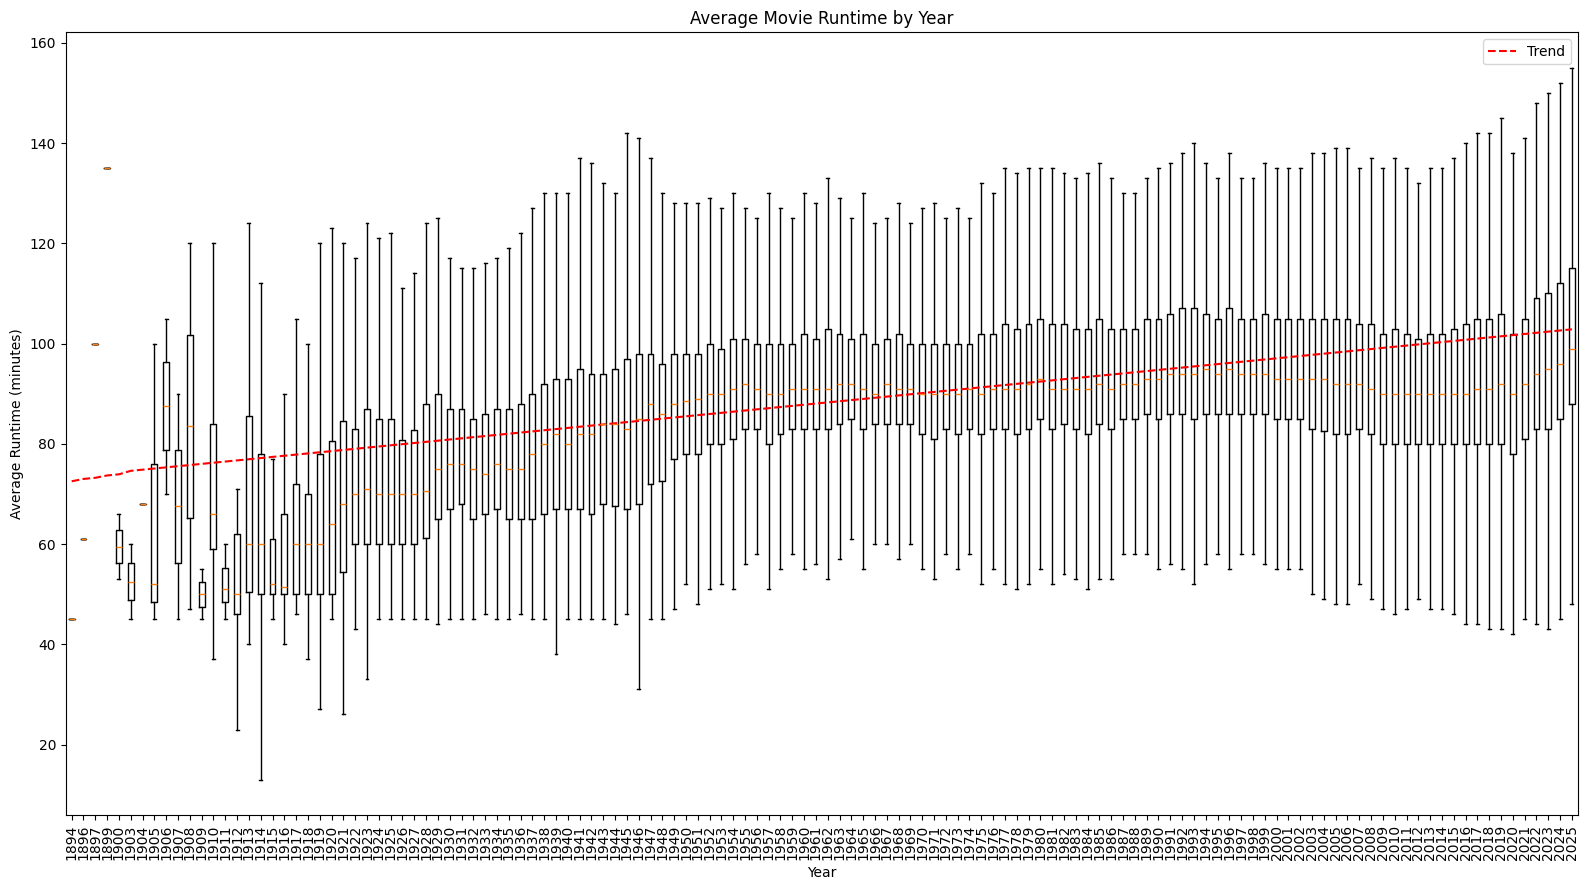

Průměrná délka filmu v období je: 94.44925663663076 minut.
Trend je vzestupný, sklon je:0.23067461409570295 minut, p hodnota se rovná: 0.0.


In [65]:
#using the function
mov_period_analysis()